In [2]:
import torch
import json
from ca_sae.sae.ca_sae import ClassAlignedSAE
import matplotlib.pyplot as plt

In [3]:
with open("../experiment_results/m_honesty/batch_topk_63_empirical_honesty_estimated.json") as f:
    features_data = json.load(f)

In [4]:
def claimed_class_counts(data):
    """
    Return a torch tensor containing the number of claimed classes
    for each feature.

    Example:
        feature 0 -> 2 claimed classes
        feature 1 -> 13 claimed classes
        feature 2 -> 0 claimed classes
    """
    return torch.tensor(
        [len(feature["claimed_classes"]) for feature in data["features"]],
        dtype=torch.long,
    )


In [5]:
empirical_ks = claimed_class_counts(features_data)

In [6]:
ca_sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_tight_l0_agr")
ca_sae.eval()

ca_ks = 5*4096 *  torch.softmax(ca_sae.budget_vector, dim=0)

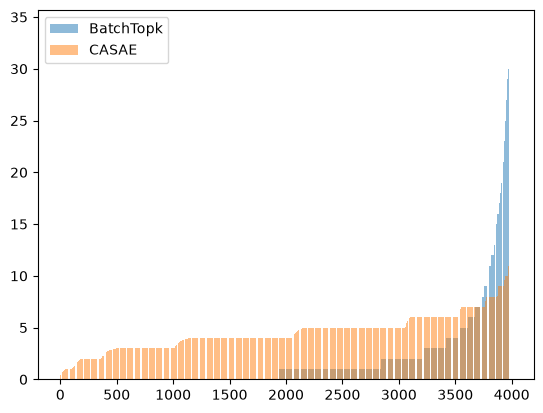

In [7]:
emp = sorted(empirical_ks)[:-100]
cas = sorted(ca_ks.detach().cpu())[:-100]
plt.bar(range(len(emp)), emp, alpha=0.5, label="BatchTopk")
plt.bar(range(len(cas)), cas, alpha=0.5, label="CASAE")
plt.legend()
plt.show()